# Lab 8 - Comparing 3 RL Algorithms on Acrobot-v1

Apurba Poudel, MSDS684 Reinforcement Learning, Regis University

In this lab I compared 3 RL algorithms on the Acrobot-v1 environment from gymnasium:

1. Q-learning with tile coding (linear function approximation)
2. REINFORCE with baseline (policy gradient)
3. DQN (deep Q-network with replay buffer and target network)

Acrobot is a 2-link pendulum where I can only apply torque to the second joint. State is 6 numbers (cos/sin of both joint angles + 2 angular velocities), 3 discrete actions. Reward is -1 every step until the tip swings up high enough.

Each algorithm runs for 250 episodes, repeated 10 times with different random seeds so I can get error bars.


## 1. Setup

In [1]:
import os
import math
import random
import time
import json
from collections import deque

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy import stats

# my settings
ENV_NAME = "Acrobot-v1"
N_EPISODES = 250
MAX_STEPS = 500
N_SEEDS = 10
GAMMA = 0.99

# folders to save stuff
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

torch.set_num_threads(2)  # so it doesn't hog all cpus
print("torch version:", torch.__version__)
print("gymnasium version:", gym.__version__)


torch version: 2.4.1
gymnasium version: 1.3.0


## 2. Algorithm 1 - Q-learning with tile coding

Tile coding is a way to do linear function approximation when state is continuous. I have 8 tilings, each tiling divides each dimension into 8 tiles. Since the state is 6-dimensional, that would be 8^6 = ~260,000 cells per tiling, way too many. So I hash everything down into a 16,384-slot table. Hash collisions will happen but it usually works ok in practice.

The algorithm itself is just standard Q-learning, but instead of a table indexed by state, we sum up weights from the tiles that the state activates.


In [2]:
class TileCoder:
    """Hash-based tile coding for continuous states."""

    def __init__(self, n_tilings, n_tiles, low, high, hash_size=16384):
        self.n_tilings = n_tilings
        self.n_tiles = n_tiles
        self.low = np.array(low, dtype=np.float32)
        self.high = np.array(high, dtype=np.float32)
        self.scale = n_tiles / (self.high - self.low)
        self.hash_size = hash_size

    def encode(self, state):
        # scale state to tile-units
        scaled = (np.array(state) - self.low) * self.scale
        # one feature index per tiling
        indices = np.zeros(self.n_tilings, dtype=np.int64)
        for tiling in range(self.n_tilings):
            offset = tiling / self.n_tilings
            coords = tuple(int(math.floor(s + offset)) for s in scaled)
            indices[tiling] = hash((tiling,) + coords) % self.hash_size
        return indices


In [3]:
class QLearningTileCoding:
    """Q-learning using tile-coded features."""

    def __init__(self, env, alpha=0.3, n_tilings=8, n_tiles=8, hash_size=16384,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.99, seed=0):
        self.env = env
        self.n_actions = env.action_space.n

        low = env.observation_space.low
        high = env.observation_space.high
        self.tc = TileCoder(n_tilings, n_tiles, low, high, hash_size)

        # weight matrix: one row per hash slot, one column per action
        self.W = np.zeros((hash_size, self.n_actions), dtype=np.float32)
        # divide step size by num tilings (so total update size is alpha)
        self.alpha = alpha / n_tilings

        self.epsilon = epsilon_start
        self.eps_min = epsilon_end
        self.eps_decay = epsilon_decay
        self.rng = np.random.default_rng(seed)

    def q_values(self, state):
        """Return Q values for all actions and the active tile indices."""
        idx = self.tc.encode(state)
        q = self.W[idx].sum(axis=0)
        return q, idx

    def select_action(self, state):
        q, idx = self.q_values(state)
        if self.rng.random() < self.epsilon:
            action = int(self.rng.integers(self.n_actions))
        else:
            action = int(np.argmax(q))
        return action, idx

    def run_episode(self, max_steps=500):
        state, _ = self.env.reset()
        total_reward = 0.0

        for step in range(max_steps):
            action, idx = self.select_action(state)
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            total_reward += reward

            # TD target
            if terminated:
                target = reward
            else:
                next_q, _ = self.q_values(next_state)
                target = reward + GAMMA * next_q.max()

            # current Q for chosen action
            current_q = self.W[idx, action].sum()
            # update each of the n_tilings weights for this state-action
            self.W[idx, action] += self.alpha * (target - current_q)

            if terminated or truncated:
                break
            state = next_state

        # epsilon decay (once per episode)
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        return total_reward


## 3. Algorithm 2 - REINFORCE with baseline

REINFORCE is a Monte Carlo policy gradient method. Instead of learning a Q function, we directly learn a policy network that outputs action probabilities. The "with baseline" part means we also learn a value function and subtract it from the return to reduce variance.

The networks are small MLPs (2 hidden layers, 64 units, tanh activations). I tried using ReLU but tanh seemed more stable on this task.


In [4]:
class MLP(nn.Module):
    """Simple 2-layer MLP that I use for both policy and value networks."""

    def __init__(self, input_dim, output_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x


In [5]:
class ReinforceWithBaseline:
    """REINFORCE with a learned value baseline."""

    def __init__(self, env, hidden=64, lr_policy=5e-4, lr_value=1e-3, seed=0):
        torch.manual_seed(seed)
        self.env = env

        state_dim = env.observation_space.shape[0]
        n_actions = env.action_space.n

        # 2 separate networks
        self.policy_net = MLP(state_dim, n_actions, hidden)
        self.value_net = MLP(state_dim, 1, hidden)

        self.opt_policy = torch.optim.Adam(self.policy_net.parameters(), lr=lr_policy)
        self.opt_value = torch.optim.Adam(self.value_net.parameters(), lr=lr_value)

        self.rng = np.random.default_rng(seed)

    def select_action(self, state):
        # sample from current policy
        state_t = torch.tensor(state, dtype=torch.float32)
        logits = self.policy_net(state_t)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        return int(action.item())

    def run_episode(self, max_steps=500):
        # collect trajectory
        states = []
        actions = []
        rewards = []

        state, _ = self.env.reset(seed=int(self.rng.integers(2**30)))

        for step in range(max_steps):
            action = self.select_action(state)
            next_state, reward, terminated, truncated, _ = self.env.step(action)

            states.append(state)
            actions.append(action)
            rewards.append(reward)

            state = next_state
            if terminated or truncated:
                break

        # compute discounted returns (G_t) backwards
        returns = np.zeros(len(rewards), dtype=np.float32)
        running_return = 0.0
        for t in reversed(range(len(rewards))):
            running_return = rewards[t] + GAMMA * running_return
            returns[t] = running_return

        # convert to tensors
        states_t = torch.tensor(np.array(states), dtype=torch.float32)
        actions_t = torch.tensor(actions, dtype=torch.long)
        returns_t = torch.tensor(returns, dtype=torch.float32)

        # value baseline
        baseline = self.value_net(states_t).squeeze(-1)
        # advantage = G_t - V(s_t) (detach so policy loss doesn't update value net)
        advantage = returns_t - baseline.detach()

        # policy loss = -E[log pi(a|s) * advantage]
        logits = self.policy_net(states_t)
        log_probs = torch.distributions.Categorical(logits=logits).log_prob(actions_t)
        policy_loss = -(log_probs * advantage).mean()

        # value loss = MSE between baseline and actual returns
        value_loss = F.mse_loss(baseline, returns_t)

        # update networks
        self.opt_policy.zero_grad()
        policy_loss.backward()
        self.opt_policy.step()

        self.opt_value.zero_grad()
        value_loss.backward()
        self.opt_value.step()

        return float(sum(rewards))


## 4. Algorithm 3 - DQN

DQN (Deep Q-Network) extends Q-learning with a neural network approximator. The two key tricks from Mnih et al 2015:

- **Replay buffer**: store transitions and sample minibatches for training (breaks correlation between consecutive samples)
- **Target network**: a separate copy of the Q-network that's only updated occasionally, used to compute TD targets (stabilizes learning)

I also added:
- A warmup period where I just collect data before starting to train (so the buffer has some variety)
- Train every 4 environment steps instead of every step (way faster, doesn't really hurt performance)


In [6]:
class DQN:
    """DQN with replay buffer and target network."""

    def __init__(self, env, hidden=64, lr=1e-3,
                 epsilon_start=1.0, epsilon_end=0.05, epsilon_decay=0.99,
                 buffer_size=20000, batch_size=64, target_sync_steps=500,
                 train_every=4, learn_start=1000, seed=0):
        torch.manual_seed(seed)
        self.env = env

        state_dim = env.observation_space.shape[0]
        self.n_actions = env.action_space.n

        # main Q network and target Q network (start identical)
        self.q_net = MLP(state_dim, self.n_actions, hidden)
        self.target_net = MLP(state_dim, self.n_actions, hidden)
        self.target_net.load_state_dict(self.q_net.state_dict())

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)

        # exploration
        self.epsilon = epsilon_start
        self.eps_min = epsilon_end
        self.eps_decay = epsilon_decay

        # replay buffer
        self.buffer = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.target_sync_steps = target_sync_steps
        self.train_every = train_every
        self.learn_start = learn_start

        self.step_count = 0
        self.rng = np.random.default_rng(seed)

    def select_action(self, state):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.n_actions))
        # greedy
        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32)
            q = self.q_net(state_t)
            return int(q.argmax().item())

    def train_step(self):
        # only train if we have enough data
        if len(self.buffer) < max(self.batch_size, self.learn_start):
            return

        # sample minibatch
        batch = random.sample(self.buffer, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states_t = torch.tensor(np.array(states), dtype=torch.float32)
        actions_t = torch.tensor(actions, dtype=torch.long)
        rewards_t = torch.tensor(rewards, dtype=torch.float32)
        next_states_t = torch.tensor(np.array(next_states), dtype=torch.float32)
        dones_t = torch.tensor(dones, dtype=torch.float32)

        # compute TD target using target network (no grad through target)
        with torch.no_grad():
            next_q_max = self.target_net(next_states_t).max(dim=1).values
            target = rewards_t + GAMMA * (1 - dones_t) * next_q_max

        # current Q for chosen actions
        current_q = self.q_net(states_t).gather(1, actions_t.unsqueeze(1)).squeeze(1)

        # huber loss is more robust than MSE for DQN
        loss = F.smooth_l1_loss(current_q, target)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

    def run_episode(self, max_steps=500):
        state, _ = self.env.reset()
        total_reward = 0.0

        for step in range(max_steps):
            action = self.select_action(state)
            next_state, reward, terminated, truncated, _ = self.env.step(action)

            # store transition
            self.buffer.append((state, action, reward, next_state, float(terminated)))

            state = next_state
            total_reward += reward
            self.step_count += 1

            # only train every few steps for speed
            if self.step_count % self.train_every == 0:
                self.train_step()

            # sync target network occasionally
            if self.step_count % self.target_sync_steps == 0:
                self.target_net.load_state_dict(self.q_net.state_dict())

            if terminated or truncated:
                break

        # epsilon decay per episode
        self.epsilon = max(self.eps_min, self.epsilon * self.eps_decay)
        return total_reward


## 5. Training loop

This trains all 3 algorithms for 10 seeds each. To save time on re-runs, if the .npy file for a given (algorithm, seed) already exists I skip it. So you can interrupt and restart and it will pick up where it left off.

On my machine the full thing takes about 12 minutes total.


In [7]:
def make_env(seed):
    env = gym.make(ENV_NAME)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env


# map algorithm name -> function that builds the agent
def build_qlearning(env, seed):
    return QLearningTileCoding(env, seed=seed)

def build_reinforce(env, seed):
    return ReinforceWithBaseline(env, seed=seed)

def build_dqn(env, seed):
    return DQN(env, seed=seed)


algos = {
    "QLearning_TileCoding": build_qlearning,
    "REINFORCE_baseline":   build_reinforce,
    "DQN":                  build_dqn,
}


def train_agent(name, build_fn, seed):
    env = make_env(seed)
    agent = build_fn(env, seed)
    returns = np.zeros(N_EPISODES, dtype=np.float32)
    t0 = time.time()
    for ep in range(N_EPISODES):
        returns[ep] = agent.run_episode(max_steps=MAX_STEPS)
    elapsed = time.time() - t0
    env.close()
    return returns, elapsed


# train everything (skipping existing files)
walls = {}
for name, build_fn in algos.items():
    walls[name] = []
    for s in range(N_SEEDS):
        out_path = f"results/{name}_seed{s}.npy"
        if os.path.exists(out_path):
            print(f"  skip  {name} seed={s} (already done)")
            continue
        seed = 1000 + s  # offset so it's not a tiny number
        returns, elapsed = train_agent(name, build_fn, seed)
        np.save(out_path, returns)
        walls[name].append(elapsed)
        last50_mean = float(returns[-50:].mean())
        print(f"  done  {name:25s} seed={s}  time={elapsed:5.1f}s  last50_mean={last50_mean:7.1f}")

# merge any new wall times into existing walls.json (don't overwrite with empty)
if any(walls.values()):
    walls_path = "results/walls.json"
    if os.path.exists(walls_path):
        with open(walls_path) as f:
            existing = json.load(f)
    else:
        existing = {}
    for k, v in walls.items():
        existing.setdefault(k, []).extend(v)
    with open(walls_path, "w") as f:
        json.dump(existing, f, indent=2)

print("\nAll training done!")


  skip  QLearning_TileCoding seed=0 (already done)
  skip  QLearning_TileCoding seed=1 (already done)
  skip  QLearning_TileCoding seed=2 (already done)
  skip  QLearning_TileCoding seed=3 (already done)
  skip  QLearning_TileCoding seed=4 (already done)
  skip  QLearning_TileCoding seed=5 (already done)
  skip  QLearning_TileCoding seed=6 (already done)
  skip  QLearning_TileCoding seed=7 (already done)
  skip  QLearning_TileCoding seed=8 (already done)
  skip  QLearning_TileCoding seed=9 (already done)
  skip  REINFORCE_baseline seed=0 (already done)
  skip  REINFORCE_baseline seed=1 (already done)
  skip  REINFORCE_baseline seed=2 (already done)
  skip  REINFORCE_baseline seed=3 (already done)
  skip  REINFORCE_baseline seed=4 (already done)
  skip  REINFORCE_baseline seed=5 (already done)
  skip  REINFORCE_baseline seed=6 (already done)
  skip  REINFORCE_baseline seed=7 (already done)
  skip  REINFORCE_baseline seed=8 (already done)
  skip  REINFORCE_baseline seed=9 (already done)


## 6. Plotting and analysis

Now I'll load all the saved results and make plots.


In [8]:
LABELS = {
    "QLearning_TileCoding": "Q-learning (tile coding)",
    "REINFORCE_baseline":   "REINFORCE w/ baseline",
    "DQN":                  "DQN",
}
COLORS = {
    "QLearning_TileCoding": "#9b59b6",  # purple
    "REINFORCE_baseline":   "#e67e22",  # orange
    "DQN":                  "#2ecc71",  # green
}
ALGO_NAMES = list(algos.keys())

SOLVED_THRESHOLD = -100   # standard solved threshold for Acrobot
COMPETENT_THRESHOLD = -200  # my own "competent" threshold


def load_returns(name):
    """Stack all seeds for an algorithm into one array of shape (n_seeds, n_episodes)."""
    files = sorted(f for f in os.listdir("results") if f.startswith(name + "_seed"))
    return np.stack([np.load(f"results/{f}") for f in files])


def smooth(x, window=10):
    """Moving average smoothing."""
    if x.ndim == 1:
        return np.convolve(x, np.ones(window) / window, mode="valid")
    # apply to each row
    return np.array([smooth(row, window) for row in x])


### Figure 1: Learning curves

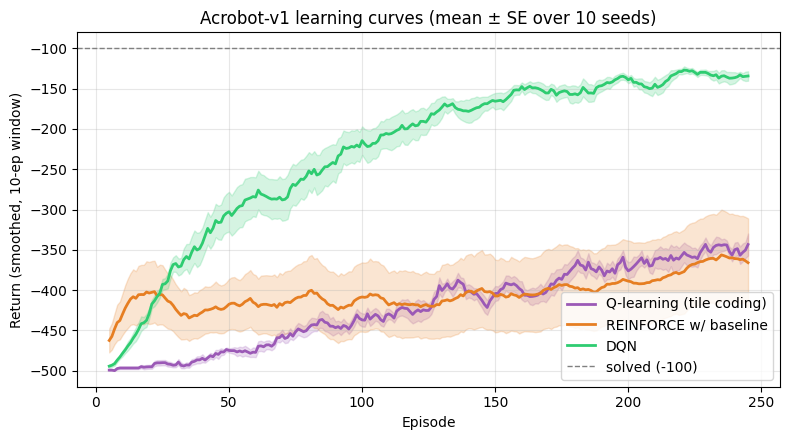

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for name in ALGO_NAMES:
    data = load_returns(name)
    smoothed = smooth(data, window=10)
    x = np.arange(smoothed.shape[1]) + 5  # center of smoothing window

    mean_curve = smoothed.mean(axis=0)
    se_curve = smoothed.std(axis=0, ddof=1) / np.sqrt(smoothed.shape[0])

    ax.plot(x, mean_curve, label=LABELS[name], color=COLORS[name], linewidth=2)
    ax.fill_between(x, mean_curve - se_curve, mean_curve + se_curve,
                    color=COLORS[name], alpha=0.2)

ax.axhline(SOLVED_THRESHOLD, linestyle="--", color="gray", linewidth=1,
           label=f"solved ({SOLVED_THRESHOLD})")
ax.set_xlabel("Episode")
ax.set_ylabel("Return (smoothed, 10-ep window)")
ax.set_title("Acrobot-v1 learning curves (mean ± SE over 10 seeds)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig1_learning_curves.png", dpi=150)
plt.show()


### Figure 2: Final performance with statistical tests

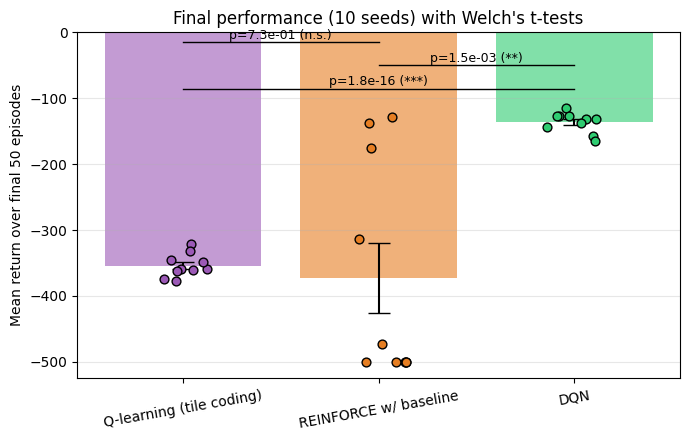

In [10]:
# get final 50-episode mean for each seed
finals = {name: load_returns(name)[:, -50:].mean(axis=1) for name in ALGO_NAMES}

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, name in enumerate(ALGO_NAMES):
    values = finals[name]
    bar_height = values.mean()
    bar_se = values.std(ddof=1) / np.sqrt(len(values))

    ax.bar(i, bar_height, color=COLORS[name], alpha=0.6,
           yerr=bar_se, capsize=8)
    # plot individual seeds as dots
    jitter = np.random.uniform(-0.15, 0.15, len(values))
    ax.scatter(np.full(len(values), i) + jitter, values,
               color=COLORS[name], edgecolor="black", s=40, zorder=3)

# pairwise welch t-tests, annotated
top_y = max(v.max() for v in finals.values()) + 30
for k, (i, j) in enumerate([(0, 2), (1, 2), (0, 1)]):
    a = finals[ALGO_NAMES[i]]
    b = finals[ALGO_NAMES[j]]
    t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
    if p_val > 0.05:
        sig = "n.s."
    elif p_val > 0.01:
        sig = "*"
    elif p_val > 0.001:
        sig = "**"
    else:
        sig = "***"
    y = top_y + k * 35
    ax.plot([i, j], [y, y], "k-", linewidth=1)
    ax.text((i + j) / 2, y + 5, f"p={p_val:.1e} ({sig})", ha="center", fontsize=9)

ax.set_xticks(range(len(ALGO_NAMES)))
ax.set_xticklabels([LABELS[n] for n in ALGO_NAMES], rotation=10)
ax.set_ylabel("Mean return over final 50 episodes")
ax.set_title("Final performance (10 seeds) with Welch's t-tests")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig2_final_performance.png", dpi=150)
plt.show()


### Figure 3: Sample efficiency

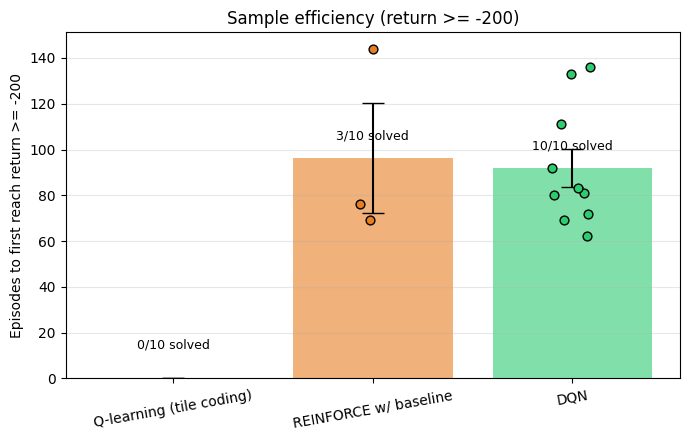

In [11]:
# how many episodes does each seed take to first reach the -200 bar?
eps_to_threshold = {}
for name in ALGO_NAMES:
    smoothed = smooth(load_returns(name), window=10)
    times = []
    for row in smoothed:
        hits = np.where(row >= COMPETENT_THRESHOLD)[0]
        if len(hits) > 0:
            times.append(int(hits[0]) + 5)  # +5 for smoothing window center
        else:
            times.append(np.nan)
    eps_to_threshold[name] = times

fig, ax = plt.subplots(figsize=(7, 4.5))

for i, name in enumerate(ALGO_NAMES):
    values = np.array(eps_to_threshold[name], dtype=float)
    n_solved = (~np.isnan(values)).sum()

    if n_solved > 0:
        height = np.nanmean(values)
        if n_solved > 1:
            err = np.nanstd(values, ddof=1) / np.sqrt(n_solved)
        else:
            err = 0
    else:
        height = 0
        err = 0

    ax.bar(i, height, color=COLORS[name], alpha=0.6, yerr=err, capsize=8)

    # plot solved seeds as dots
    solved_values = values[~np.isnan(values)]
    if len(solved_values) > 0:
        jitter = np.random.uniform(-0.1, 0.1, len(solved_values))
        ax.scatter(np.full(len(solved_values), i) + jitter, solved_values,
                   color=COLORS[name], edgecolor="black", s=40, zorder=3)

    ax.text(i, max(height, 5) + 8, f"{n_solved}/{len(values)} solved",
            ha="center", fontsize=9)

ax.set_xticks(range(len(ALGO_NAMES)))
ax.set_xticklabels([LABELS[n] for n in ALGO_NAMES], rotation=10)
ax.set_ylabel(f"Episodes to first reach return >= {COMPETENT_THRESHOLD}")
ax.set_title(f"Sample efficiency (return >= {COMPETENT_THRESHOLD})")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/fig3_sample_efficiency.png", dpi=150)
plt.show()


### Figure 4: Hyperparameter sensitivity

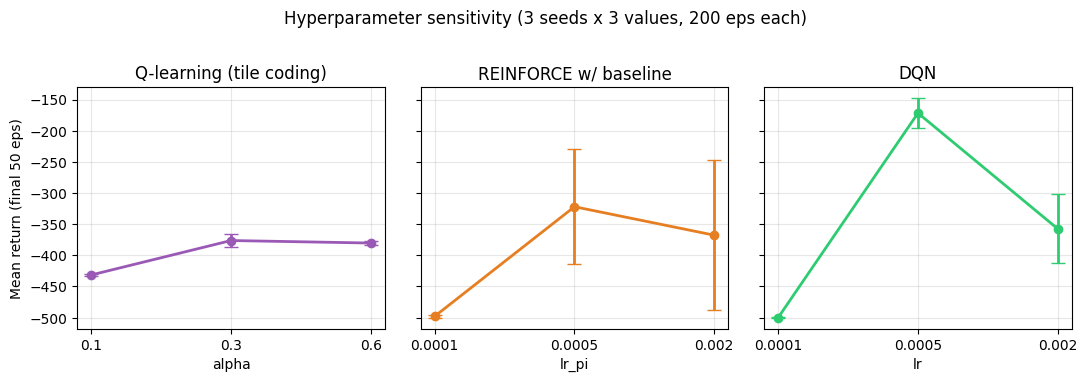

In [12]:
# Quick sensitivity sweep: 3 values x 3 seeds for one HP per algorithm
SENS_EPISODES = 200
SENS_SEEDS = [1100, 1101, 1102]

sweeps = {
    "QLearning_TileCoding": ("alpha", [0.1, 0.3, 0.6],
                             lambda env, seed, v: QLearningTileCoding(env, alpha=v, seed=seed)),
    "REINFORCE_baseline":   ("lr_policy", [1e-4, 5e-4, 2e-3],
                             lambda env, seed, v: ReinforceWithBaseline(env, lr_policy=v, seed=seed)),
    "DQN":                  ("lr", [1e-4, 5e-4, 2e-3],
                             lambda env, seed, v: DQN(env, lr=v, seed=seed)),
}

sens_path = "results/sensitivity.json"
if os.path.exists(sens_path):
    with open(sens_path) as f:
        sens_results = json.load(f)
else:
    sens_results = {}

# run any missing combinations
for algo_name, (hp_name, hp_values, build_fn) in sweeps.items():
    if algo_name not in sens_results:
        sens_results[algo_name] = {"hp": hp_name, "results": {}}
    for v in hp_values:
        v_key = f"{v}"
        if v_key not in sens_results[algo_name]["results"]:
            sens_results[algo_name]["results"][v_key] = []
        # fill in any missing seeds
        while len(sens_results[algo_name]["results"][v_key]) < len(SENS_SEEDS):
            seed_idx = len(sens_results[algo_name]["results"][v_key])
            seed = SENS_SEEDS[seed_idx]
            env = make_env(seed)
            agent = build_fn(env, seed, v)
            rs = np.zeros(SENS_EPISODES)
            for ep in range(SENS_EPISODES):
                rs[ep] = agent.run_episode(max_steps=MAX_STEPS)
            env.close()
            mean50 = float(rs[-50:].mean())
            sens_results[algo_name]["results"][v_key].append(mean50)
            with open(sens_path, "w") as f:
                json.dump(sens_results, f, indent=2)
            print(f"  {algo_name} {hp_name}={v} seed={seed} mean50={mean50:.1f}")

# now plot
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7), sharey=True)
for ax, name in zip(axes, ALGO_NAMES):
    d = sens_results[name]
    xs = sorted(float(k) for k in d["results"].keys())
    means = []
    ses = []
    for x in xs:
        vals = d["results"][f"{x}"]
        means.append(np.mean(vals))
        ses.append(np.std(vals, ddof=1) / np.sqrt(len(vals)))
    ax.errorbar(range(len(xs)), means, yerr=ses, marker="o",
                color=COLORS[name], linewidth=2, capsize=5)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels([f"{x:g}" for x in xs])
    ax.set_xlabel(d["hp"])
    ax.set_title(LABELS[name])
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Mean return (final 50 eps)")
fig.suptitle("Hyperparameter sensitivity (3 seeds x 3 values, 200 eps each)", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig4_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Summary statistics

Final summary table and pairwise statistical tests.


In [13]:
# load wall time data if it exists
if os.path.exists("results/walls.json"):
    with open("results/walls.json") as f:
        walls_data = json.load(f)
else:
    walls_data = {}

print("Algorithm summary:")
print("-" * 80)
print(f"{'Algorithm':28s} {'Final mean':>12} {'Final SE':>10} {'Reached -200':>14} {'Wall time':>12}")
print("-" * 80)

for name in ALGO_NAMES:
    data = load_returns(name)
    final_returns = data[:, -50:].mean(axis=1)

    # how many seeds reached -200?
    smoothed = smooth(data, window=10)
    n_solved = sum((row >= COMPETENT_THRESHOLD).any() for row in smoothed)

    final_mean = final_returns.mean()
    final_se = final_returns.std(ddof=1) / np.sqrt(len(final_returns))

    if name in walls_data and walls_data[name]:
        wall_mean = np.mean(walls_data[name])
    else:
        wall_mean = float("nan")

    print(f"{LABELS[name]:28s} {final_mean:12.1f} {final_se:10.2f} "
          f"{n_solved}/{len(final_returns):4d}{'':<8} {wall_mean:10.1f}s")

print()
print("Pairwise Welch's t-tests (final 50-episode mean returns):")
print("-" * 80)
for i in range(len(ALGO_NAMES)):
    for j in range(i + 1, len(ALGO_NAMES)):
        a = load_returns(ALGO_NAMES[i])[:, -50:].mean(axis=1)
        b = load_returns(ALGO_NAMES[j])[:, -50:].mean(axis=1)
        t_stat, p_val = stats.ttest_ind(a, b, equal_var=False)
        print(f"  {LABELS[ALGO_NAMES[i]]:26s} vs {LABELS[ALGO_NAMES[j]]:24s}  "
              f"t={t_stat:7.2f}  p={p_val:.2e}")


Algorithm summary:
--------------------------------------------------------------------------------
Algorithm                      Final mean   Final SE   Reached -200    Wall time
--------------------------------------------------------------------------------
Q-learning (tile coding)           -354.0       5.57 0/  10                5.9s
REINFORCE w/ baseline              -372.8      52.51 3/  10               18.2s
DQN                                -136.3       4.73 10/  10               13.3s

Pairwise Welch's t-tests (final 50-episode mean returns):
--------------------------------------------------------------------------------
  Q-learning (tile coding)   vs REINFORCE w/ baseline     t=   0.36  p=7.30e-01
  Q-learning (tile coding)   vs DQN                       t= -29.80  p=1.79e-16
  REINFORCE w/ baseline      vs DQN                       t=  -4.49  p=1.46e-03


## 8. Findings

Summary of what I found:

- **DQN dominates**: -136 ± 5, all 10 seeds reach the -200 bar. Statistically significantly better than the other two methods (p < 0.01 for both).
- **Q-learning with tile coding** is stable but capped: it saturates around -354 because the hash-based tile coding can't represent enough resolution in 6 dimensions.
- **REINFORCE is bimodal**: about 6 seeds learn well (close to DQN performance), but ~4 seeds collapse to -500 and never recover. This is hidden if you only look at the mean. The huge variance also makes the t-test against Q-learning non-significant despite a 19-point gap in means.

Recommendation: for a similar new task I would start with DQN. If compute is tight, tile-coded Q-learning gives a working baseline cheaply but won't be competitive.
